# Будем практиковаться классификации и кластеризации на пингвинчиках

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import sklearn as sk

## Вся предобработка из hw3

In [2]:
penguins = sns.load_dataset('penguins')
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins_clean = penguins.dropna(subset=numeric_cols, how='all').reset_index(drop=True)
def fill_sex(row):
    if pd.notna(row['sex']):
        return row['sex']
    # Если масса известна, используем её
    if pd.notna(row['body_mass_g']):
        # Вычисляем медиану массы для данного вида (по всем данным)
        median_mass = penguins_clean[penguins_clean['species'] == row['species']]['body_mass_g'].median()
        if row['body_mass_g'] > median_mass:
            return 'Male'
        else:
            return 'Female'
    # Если масса неизвестна, но известна длина клюва
    if pd.notna(row['bill_length_mm']):
        median_bill = penguins_clean[penguins_clean['species'] == row['species']]['bill_length_mm'].median()
        if row['bill_length_mm'] > median_bill:
            return 'Male'
        else:
            return 'Female'
    # Если ничего не известно, оставляем NaN
    return row['sex']

# Применяем функцию
penguins_clean['sex'] = penguins_clean.apply(fill_sex, axis=1)

# Теперь заполняем числовые пропуски медианами по группам (вид + пол)
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    penguins_clean[col] = penguins_clean.groupby(['species', 'sex'])[col].transform(lambda x: x.fillna(x.median()))
pg = penguins_clean
pg.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Попробуем решить задачу классикации пингвинов по виду

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
OHE_encoder = OneHotEncoder()
ss = StandardScaler()

num = ['body_mass_g', 'flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']
cat = ['sex']
target = 'species'

ct = ColumnTransformer([
    ('num', ss, num),
    ('cat', OHE_encoder, cat),
], remainder='drop')

X = penguins_clean[num + cat]
Y = penguins_clean[target]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('preprocessor', ct),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, Y_train)
y_pred = pipeline.predict(X_test)

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        35
   Chinstrap       1.00      1.00      1.00        12
      Gentoo       1.00      1.00      1.00        22

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



<Axes: >

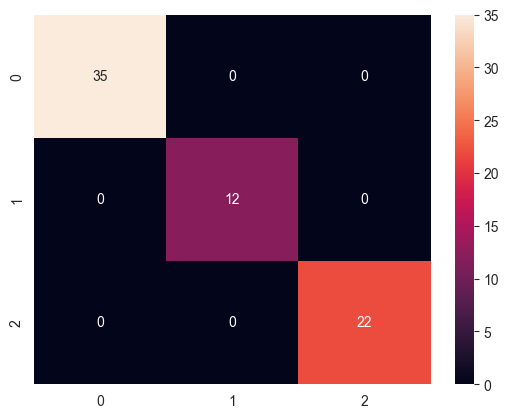

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print(classification_report(Y_test, y_pred))
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True)

In [5]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='f1_macro')
print(scores)
print(scores.mean())
print(scores.std())

[1.         0.97703479 0.97841505 1.         1.        ]
0.9910899666681351
0.010921243214499282


Задача классификации оказалась слишком классной. Теперь хочется попробовать кластеризацию 

X1 0.4769804687337651
X1 0.6395104400625511
X2 0.4841945371989328
X2 0.6440544435654981
X3 0.48747326810147845
X3 0.5744817896568322


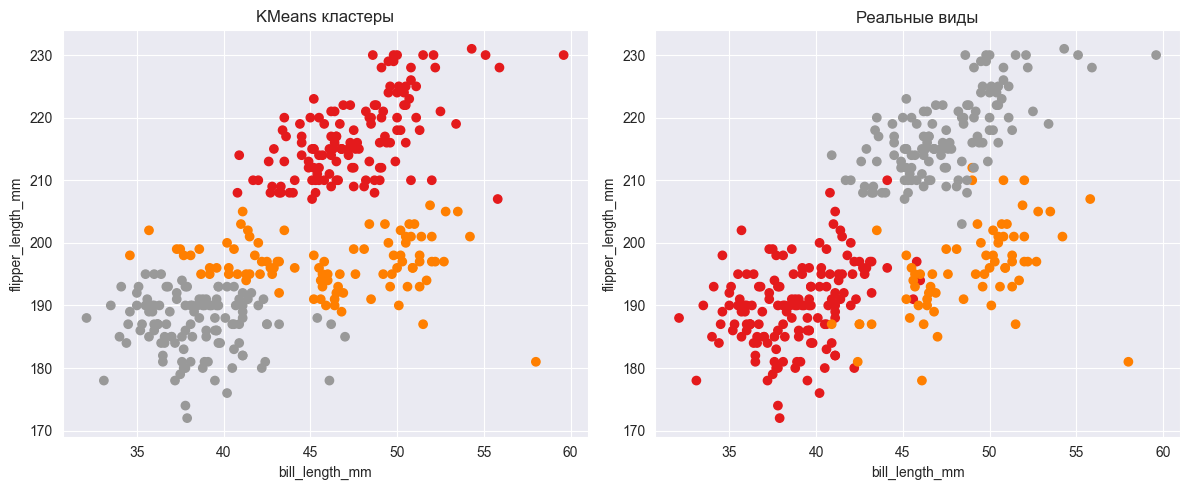

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

X1 = pg[['bill_length_mm', 'flipper_length_mm', 'bill_depth_mm']]
km1 = KMeans(n_clusters=3, random_state=42).fit(X1)
print('X1', silhouette_score(X1, km1.labels_))
print('X1', adjusted_rand_score(penguins_clean['species'], km1.labels_))


X2 = pg[['bill_length_mm', 'flipper_length_mm']]
km2 = KMeans(n_clusters=3, random_state=42).fit(X2)
print('X2', silhouette_score(X2, km2.labels_))
print('X2', adjusted_rand_score(penguins_clean['species'], km2.labels_))

X3 = pg[['bill_length_mm', 'bill_depth_mm']]
km3 = KMeans(n_clusters=3, random_state=42).fit(X3)
print('X3', silhouette_score(X3, km3.labels_))
print('X3', adjusted_rand_score(penguins_clean['species'], km3.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                                                                                                                                                                                                         
axes[0].scatter(pg['bill_length_mm'], pg['flipper_length_mm'],                                                                                            c=km2.labels_, cmap='Set1')                                                                                                                                                            
axes[0].set_title('KMeans кластеры')                                                                                                                                                                   
axes[0].set_xlabel('bill_length_mm')
axes[0].set_ylabel('flipper_length_mm')

axes[1].scatter(pg['bill_length_mm'], pg['flipper_length_mm'],
              c=pd.factorize(penguins_clean['species'])[0], cmap='Set1')
axes[1].set_title('Реальные виды')
axes[1].set_xlabel('bill_length_mm')
axes[1].set_ylabel('flipper_length_mm')

plt.tight_layout()
plt.show()

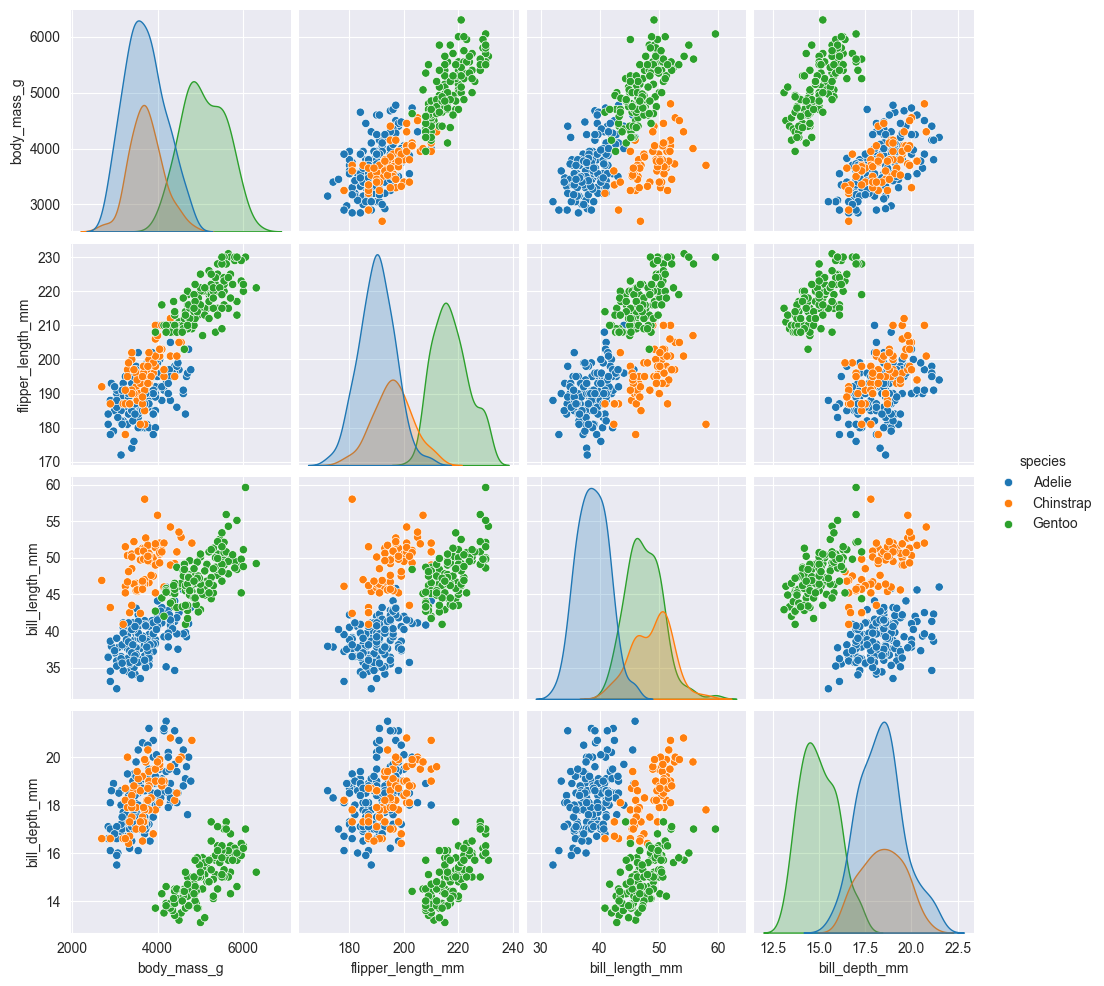

In [7]:
sns.pairplot(penguins_clean[num + ['species']], hue='species')        